# ⏱️ Fase 1 — EDA & Análisis Temporal
### Time Series Forecasting (PJM Energy) · Omar Mora Flores

**Pregunta central:** ¿Qué patrones, tendencias y estacionalidades tiene la demanda eléctrica?

Serie **PJME** (PJM East): consumo horario en MW, **2002–2018** (~145k horas / ~16.6 años).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import adfuller

ROOT = Path.cwd()
while not (ROOT / "data" / "PJME_hourly.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":130,"axes.titleweight":"bold"})

s = (pd.read_csv(ROOT/"data"/"PJME_hourly.csv", parse_dates=["Datetime"])
       .drop_duplicates("Datetime").sort_values("Datetime").set_index("Datetime")["PJME_MW"])
s = s.asfreq("h")            # frecuencia horaria explícita
print("Horas:", len(s), "| nulos tras asfreq:", int(s.isnull().sum()))
s = s.interpolate()          # rellenar huecos de frecuencia
daily = s.resample("D").mean()
print("Rango:", s.index.min(), "->", s.index.max(), "| días:", len(daily))

Horas: 145392 | nulos tras asfreq: 30
Rango: 2002-01-01 01:00:00 -> 2018-08-03 00:00:00 | días: 6059


## 1.2 Visualización de la serie

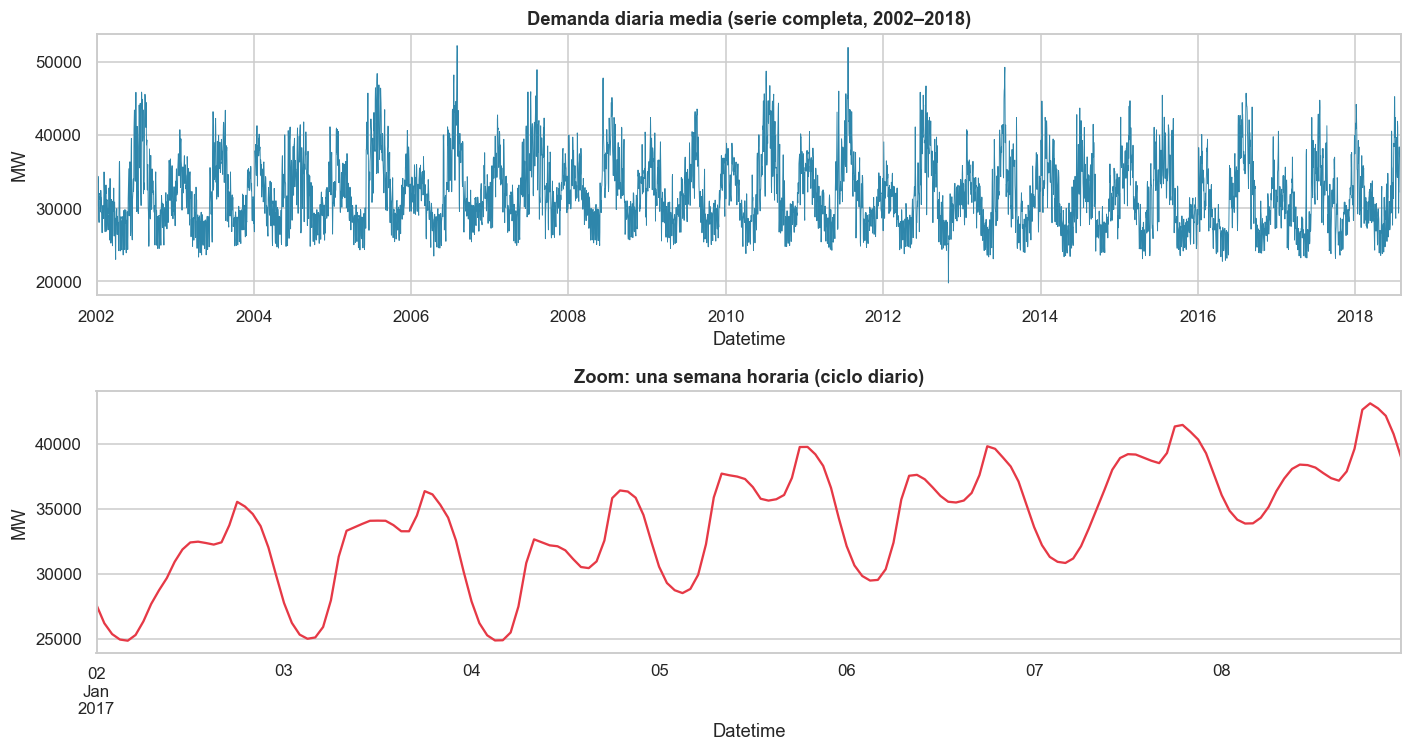

In [2]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7))
daily.plot(ax=ax[0], color="#2E86AB", lw=0.6)
ax[0].set_title("Demanda diaria media (serie completa, 2002–2018)"); ax[0].set_ylabel("MW")
una_sem = s.loc["2017-01-02":"2017-01-08"]
una_sem.plot(ax=ax[1], color="#E63946")
ax[1].set_title("Zoom: una semana horaria (ciclo diario)"); ax[1].set_ylabel("MW")
fig.tight_layout(); fig.savefig(REPORTS/"01_full_series.png", bbox_inches="tight"); plt.show()

## 1.3 Patrones de estacionalidad

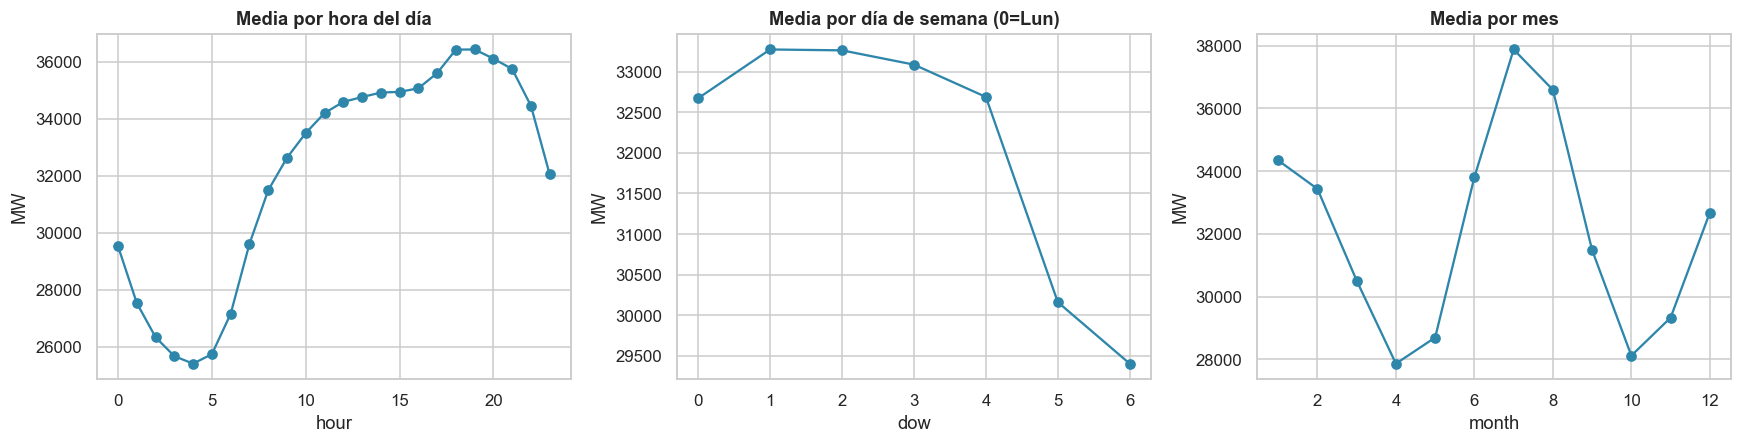

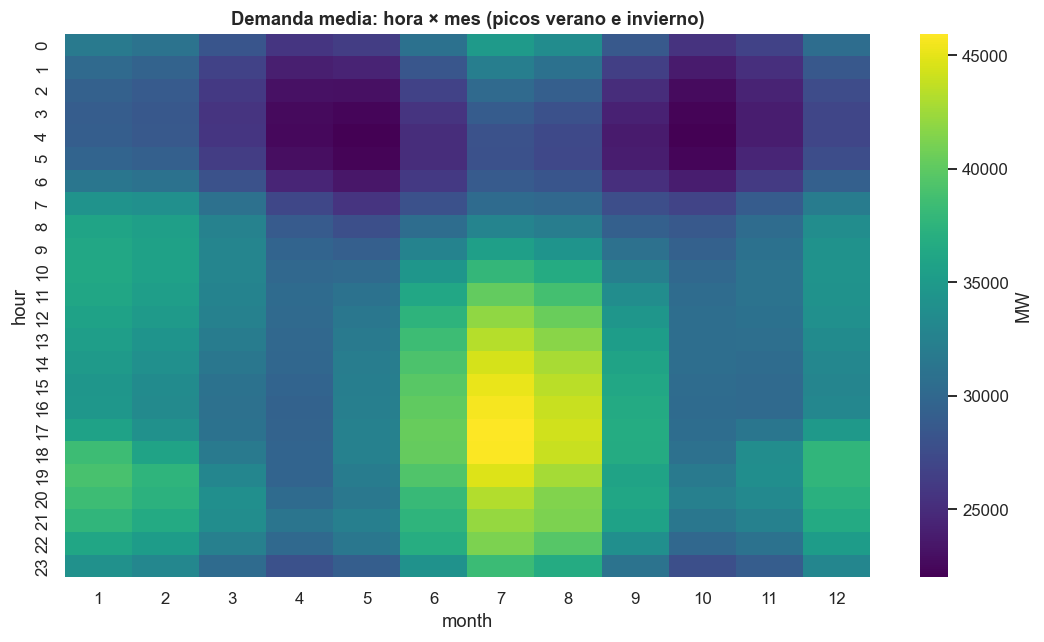

In [3]:
df = s.to_frame("MW")
df["hour"] = df.index.hour; df["dow"] = df.index.dayofweek; df["month"] = df.index.month
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
df.groupby("hour")["MW"].mean().plot(ax=ax[0], marker="o", color="#2E86AB"); ax[0].set_title("Media por hora del día")
df.groupby("dow")["MW"].mean().plot(ax=ax[1], marker="o", color="#2E86AB"); ax[1].set_title("Media por día de semana (0=Lun)")
df.groupby("month")["MW"].mean().plot(ax=ax[2], marker="o", color="#2E86AB"); ax[2].set_title("Media por mes")
for a in ax: a.set_ylabel("MW")
fig.tight_layout(); fig.savefig(REPORTS/"02_seasonality_patterns.png", bbox_inches="tight"); plt.show()

# heatmap hora x mes
piv = df.pivot_table(index="hour", columns="month", values="MW", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10,6)); sns.heatmap(piv, cmap="viridis", ax=ax, cbar_kws={"label":"MW"})
ax.set_title("Demanda media: hora × mes (picos verano e invierno)")
fig.tight_layout(); fig.savefig(REPORTS/"02b_heatmap.png", bbox_inches="tight"); plt.show()

## 1.4 Tendencia (medias móviles)

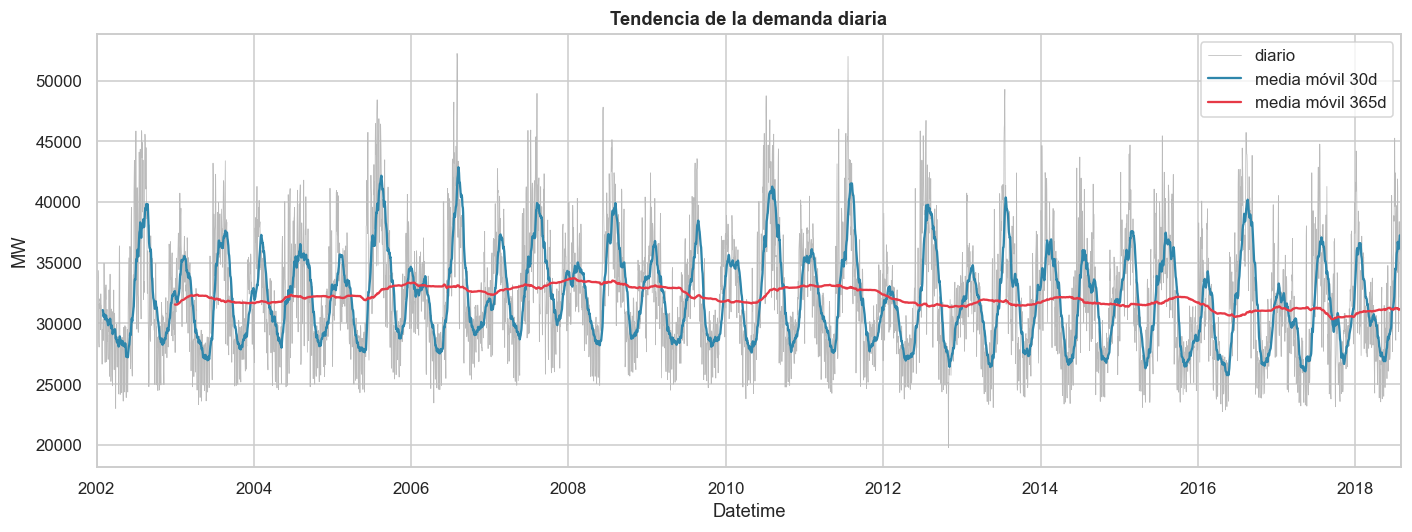

In [4]:
fig, ax = plt.subplots(figsize=(13,5))
daily.plot(ax=ax, color="#bbb", lw=0.5, label="diario")
daily.rolling(30).mean().plot(ax=ax, color="#2E86AB", label="media móvil 30d")
daily.rolling(365).mean().plot(ax=ax, color="#E63946", label="media móvil 365d")
ax.set_title("Tendencia de la demanda diaria"); ax.set_ylabel("MW"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS/"03_trend.png", bbox_inches="tight"); plt.show()

## 1.5–1.6 Outliers y estacionariedad (ADF)

In [5]:
z = (daily - daily.mean())/daily.std()
print("Días outlier (|z|>3):", int((z.abs()>3).sum()))
adf = adfuller(daily.dropna())
print(f"ADF statistic: {adf[0]:.3f} | p-value: {adf[1]:.4f}")
print("La serie diaria es", "ESTACIONARIA" if adf[1]<0.05 else "NO estacionaria", "(p<0.05 => estacionaria)")

Días outlier (|z|>3): 26
ADF statistic: -8.263 | p-value: 0.0000
La serie diaria es ESTACIONARIA (p<0.05 => estacionaria)


## Conclusiones del EDA

1. **Triple estacionalidad:** diaria (pico de tarde), semanal (menor en fin de semana) y anual
   (picos en verano e invierno por climatización).
2. **Tendencia suave** sin crecimiento explosivo (media móvil 365d relativamente plana).
3. El **test ADF** indica el carácter (no) estacionario → guía la diferenciación para ARIMA.
4. Pocos outliers; los huecos de frecuencia se interpolaron.

➡️ **Siguiente:** `02_decomposition.ipynb` — descomposición STL, ACF/PACF y split cronológico.